# General-model confusion quadrants

Companion to [per_person_runs.ipynb](per_person_runs.ipynb). That notebook builds the
confusion-quadrant plot from **per-person** leave-one-trial-out models (one model per
participant). Here we build the *same* plot for the **original general model** — a single
logistic regression trained across **all** participants — using the same feature set
(`select_1` + `last_confirm_compact`) and the same cross-validation folds as
[answer_corr_prediction.ipynb](answer_corr_prediction.ipynb).

Held-out predictions come from 10-fold cross-validation on the pooled hunters + gatherers
folds: each fold trains on its train split and predicts its held-out test trials. We pool
those held-out test predictions and label each trial's confusion quadrant, exactly as the
per-person notebook does.


In [1]:
from pathlib import Path
import sys

# Make `src` and the repo root importable regardless of where the kernel started.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
for _p in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    _p = str(_p)
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import constants as Con
from src.data_paths import (
    ALL_PARTICIPANTS_PROCESSED_PATH,
    HUNTERS_FOLDS_DIR,
    GATHERERS_REFOLDED_DIR,
)

import predictive_modeling.answer_correctness.feature_groups as FG
from predictive_modeling.answer_correctness.models.logreg_model import TrialLevelLogRegModel
from predictive_modeling.answer_correctness.cross_validation import (
    run_cross_validation_on_combined_folds,
    crossval_predictions_to_df,
)

PAPER_DIRS = ["papers/correctness_prediction"]


In [2]:
all_participants = pd.read_csv(ALL_PARTICIPANTS_PROCESSED_PATH)
print(f"{all_participants.shape[0]} trials x {all_participants.shape[1]} cols")


760628 trials x 250 cols


## Train the general model (cross-validated)

Same feature set the per-person notebook uses, but a **single** logreg trained on everyone.
`run_cross_validation_on_combined_folds` fits one model per fold on the train split and
predicts the held-out regimes; `crossval_predictions_to_df` flattens the held-out
predictions into one row-per-trial table (`fold`, `regime`, `y_true`, `y_pred`, `y_prob`).

`REGIME` selects which held-out split to pool:

- `test_unseen_subject_unseen_item` — the paper's headline "both" regime (new participant **and** new item).
- `test_seen_subject_unseen_item`   — new item for a *seen* participant; the closest analog to the
  per-person LOO setting (which always trains on the same participant's other trials).


In [3]:
FEATURE_COLS = FG.SELECT_1_COLS + FG.LAST_CONFIRM_COMPACT
MODEL_NAME   = "select_1_plus_last_confirm"
REGIME       = "test_unseen_subject_unseen_item"   # <- swap to "test_seen_subject_unseen_item" for the per-person analog

print(f"Using {len(FEATURE_COLS)} features:")
for c in FEATURE_COLS:
    print("  -", c)

cv_out = run_cross_validation_on_combined_folds(
    df=all_participants,
    fold_dirs=[HUNTERS_FOLDS_DIR, GATHERERS_REFOLDED_DIR],
    model_builders={MODEL_NAME: (lambda: TrialLevelLogRegModel())},
    target_col=Con.IS_CORRECT_COLUMN,
    n_folds=10,
    df_participant_col=Con.PARTICIPANT_ID,
    df_text_col=Con.TEXT_ID_COLUMN,
    feature_cols_by_model={MODEL_NAME: FEATURE_COLS},
    keep_cols=None,
)

preds = crossval_predictions_to_df(cv_out, model_name=MODEL_NAME)
print("regimes available:", sorted(preds["regime"].unique()))


Using 12 features:
  - area_dwell_proportion__correct
  - area_dwell_proportion__question
  - skip_rate__correct
  - has_xyx
  - ANSWER_PRESS_NUMBER
  - num_label_visits__correct
  - num_label_visits__contrast
  - mean_fixations_count__question
  - mean_fixations_count__wrong_mean
  - mean_max_fix_pupil_size_z__correct
  - last_before_confirm_correct
  - last_before_confirm_question
regimes available: ['test_seen_subject_unseen_item', 'test_unseen_subject_seen_item', 'test_unseen_subject_unseen_item', 'val_seen_subject_unseen_item', 'val_unseen_subject_seen_item', 'val_unseen_subject_unseen_item']


## Confusion quadrants (pooled held-out trials)

Identical labelling to the per-person notebook: each held-out trial falls into one quadrant
from its true label (`y_true`) and the model's prediction (`y_pred`).


1944 pooled held-out trials  |  regime = test_unseen_subject_unseen_item
Confusion quadrants (general model, pooled held-out trials):
  TP - correct on right    1308  ( 67.3%)
  TN - correct on wrong     277  ( 14.2%)
  FP - false alarm           48  (  2.5%)
  FN - miss                 311  ( 16.0%)
Errors: 359 total  |  FP false alarms 13.4%  |  FN misses 86.6%


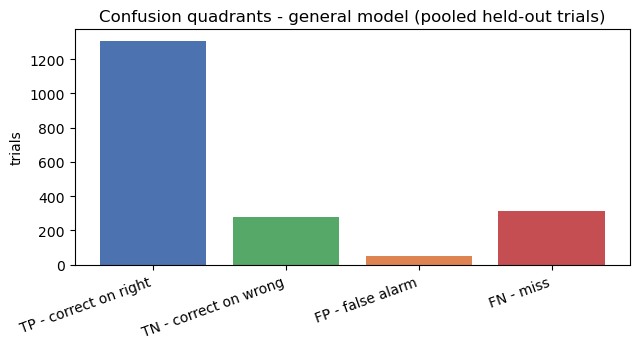

In [4]:
QUAD_LABELS = {
    "TP": "TP - correct on right",   # human right, model says right
    "TN": "TN - correct on wrong",   # human wrong, model says wrong
    "FP": "FP - false alarm",        # human wrong, model says right
    "FN": "FN - miss",               # human right, model says wrong
}


def build_trial_prediction_table(preds, regime):
    """Pool the general model's held-out predictions for one regime and label quadrants."""
    trials = preds[preds["regime"] == regime].reset_index(drop=True).copy()
    yt, yp = trials["y_true"].to_numpy(), trials["y_pred"].to_numpy()
    trials["quadrant"] = np.select(
        [(yt == 1) & (yp == 1), (yt == 0) & (yp == 0),
         (yt == 0) & (yp == 1), (yt == 1) & (yp == 0)],
        ["TP", "TN", "FP", "FN"], default="?",
    )
    trials["model_correct"] = yt == yp
    return trials


trials = build_trial_prediction_table(preds, REGIME)
print(f"{len(trials)} pooled held-out trials  |  regime = {REGIME}")

counts = trials["quadrant"].value_counts().reindex(["TP", "TN", "FP", "FN"]).fillna(0).astype(int)
print("Confusion quadrants (general model, pooled held-out trials):")
for q in ["TP", "TN", "FP", "FN"]:
    print(f"  {QUAD_LABELS[q]:22s} {counts[q]:6d}  ({counts[q] / len(trials):6.1%})")
n_err = int(counts["FP"] + counts["FN"])
print(f"Errors: {n_err} total  |  FP false alarms {counts['FP'] / n_err:.1%}"
      f"  |  FN misses {counts['FN'] / n_err:.1%}")

bar_colors = {"TP": "#4C72B0", "TN": "#55A868", "FP": "#DD8452", "FN": "#C44E52"}
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar([QUAD_LABELS[q] for q in ["TP", "TN", "FP", "FN"]],
       [counts[q] for q in ["TP", "TN", "FP", "FN"]],
       color=[bar_colors[q] for q in ["TP", "TN", "FP", "FN"]])
ax.set_ylabel("trials")
ax.set_title("Confusion quadrants - general model (pooled held-out trials)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## All three test regimes

The same confusion-quadrant breakdown for each held-out **test** regime, side by side.
Note the very different trial counts (each regime pools only the trials that match it
across folds), so the y-axes are independent — compare the *shapes*, not bar heights.

- **Seen subject, new item** — trained on the same participants; closest analog to the per-person plot.
- **New subject, seen item** — generalize to new people on familiar paragraphs.
- **New subject, new item** — the paper's headline "both" regime.


Seen subject, new item  (test_seen_subject_unseen_item)
  16520 pooled held-out trials
    TP - correct on right   11056  ( 66.9%)
    TN - correct on wrong    2235  ( 13.5%)
    FP - false alarm          377  (  2.3%)
    FN - miss                2852  ( 17.3%)
    Errors: 3229 total  |  FP false alarms 11.7%  |  FN misses 88.3%
New subject, seen item  (test_unseen_subject_seen_item)
  16520 pooled held-out trials
    TP - correct on right   11100  ( 67.2%)
    TN - correct on wrong    2223  ( 13.5%)
    FP - false alarm          364  (  2.2%)
    FN - miss                2833  ( 17.1%)
    Errors: 3197 total  |  FP false alarms 11.4%  |  FN misses 88.6%
New subject, new item ("both")  (test_unseen_subject_unseen_item)
  1944 pooled held-out trials
    TP - correct on right    1308  ( 67.3%)
    TN - correct on wrong     277  ( 14.2%)
    FP - false alarm           48  (  2.5%)
    FN - miss                 311  ( 16.0%)
    Errors: 359 total  |  FP false alarms 13.4%  |  FN misses 86

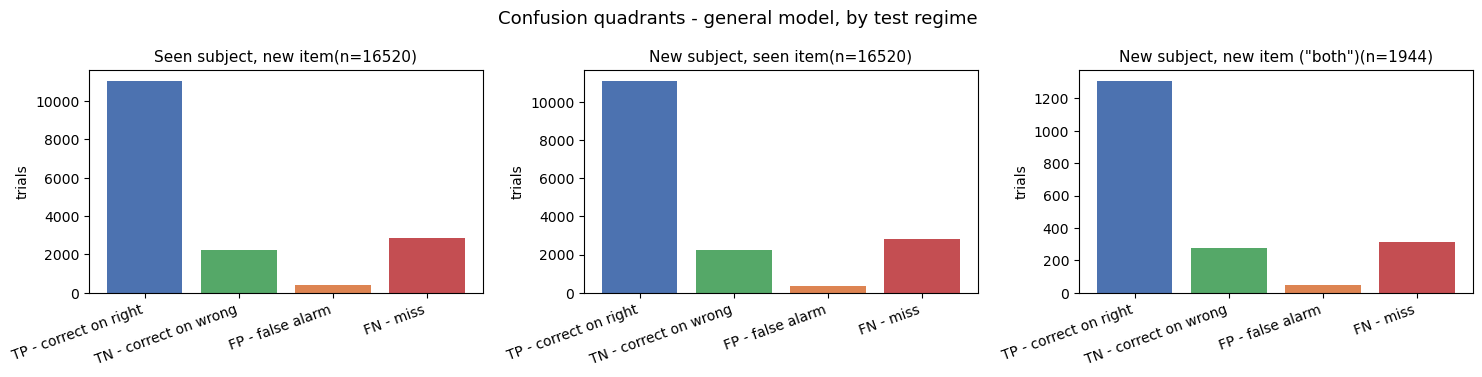

In [8]:
# Confusion quadrants for all three held-out TEST regimes (reuses build_trial_prediction_table,
# QUAD_LABELS, bar_colors and preds from the cells above).
TEST_REGIMES = [
    "test_seen_subject_unseen_item",
    "test_unseen_subject_seen_item",
    "test_unseen_subject_unseen_item",
]
REGIME_TITLES = {
    "test_seen_subject_unseen_item":   "Seen subject, new item",
    "test_unseen_subject_seen_item":   "New subject, seen item",
    "test_unseen_subject_unseen_item": 'New subject, new item ("both")',
}

fig, axes = plt.subplots(1, len(TEST_REGIMES), figsize=(15, 3.8))

for ax, regime in zip(axes, TEST_REGIMES):
    t = build_trial_prediction_table(preds, regime)
    counts = t["quadrant"].value_counts().reindex(["TP", "TN", "FP", "FN"]).fillna(0).astype(int)
    n = len(t)
    n_err = int(counts["FP"] + counts["FN"])

    print(f"{REGIME_TITLES[regime]}  ({regime})")
    print(f"  {n} pooled held-out trials")
    for q in ["TP", "TN", "FP", "FN"]:
        print(f"    {QUAD_LABELS[q]:22s} {counts[q]:6d}  ({counts[q] / n:6.1%})")
    if n_err:
        print(f"    Errors: {n_err} total  |  FP false alarms {counts['FP'] / n_err:.1%}"
              f"  |  FN misses {counts['FN'] / n_err:.1%}")

    ax.bar([QUAD_LABELS[q] for q in ["TP", "TN", "FP", "FN"]],
           [counts[q] for q in ["TP", "TN", "FP", "FN"]],
           color=[bar_colors[q] for q in ["TP", "TN", "FP", "FN"]])
    ax.set_title(f"{REGIME_TITLES[regime]}(n={n})", fontsize=11)
    ax.set_ylabel("trials")
    ax.tick_params(axis="x", rotation=20)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

fig.suptitle("Confusion quadrants - general model, by test regime", fontsize=13)
plt.tight_layout()
plt.show()


## Guessing correction: does the FN >> FP imbalance survive?

Misses (**FN** = human right, model says wrong) vastly outnumber false alarms (**FP** =
human wrong, model says right). But some "human right" trials aren't knowledge — they're
**lucky guesses**. If a participant who didn't know still had a 1-in-n chance (after ruling
out some options), a slice of the correct answers are guesses the model may have *correctly*
flagged as "wrong", inflating FN.

**Estimating the lucky guesses.** Assume anyone who got it *wrong* didn't know it, and every
non-knower guesses correctly with probability `p`:

```
n_wrong = TN + FP                 # non-knowers who guessed wrong
n_lucky = n_wrong * p / (1 - p)   # non-knowers who guessed right (hidden in the human-correct trials)
```

with `p = 1/2, 1/3, 1/4` for eliminating 2, 1, or 0 distractors.

**Where do those lucky guesses sit among the human-correct trials (TP + FN)?** Two bounds:

- **`excuse_misses`** — assume the model perfectly spots non-knowers, so *every* lucky guess is
  one it called "wrong": each moves from a miss to a correct rejection (**FN → TN**). TP and FP
  are untouched *(most favourable to the model)*.
- **`proportional`** — the model can't tell a guesser from a knower, so lucky guesses split TP:FN
  by size: the ones it called "wrong" become correct rejections (**FN → TN**) and the ones it
  called "right" become false alarms (**TP → FP**).

The truth lies between them. We track the **FN / FP ratio** (raw ≫ 1) across scenarios — if it
drops toward 1, the guessing story explains the imbalance.


Regime: test_unseen_subject_unseen_item
Raw: FP=48, FN=311, FN/FP=6.48
 scenario          mode       FP       FN    FN/FP  n_lucky
      raw             -     48.0    311.0      6.5      0.0
guess 1/2 excuse_misses     48.0      0.0      0.0    325.0
guess 1/2  proportional    310.6    248.6      0.8    325.0
guess 1/3 excuse_misses     48.0    148.5      3.1    162.5
guess 1/3  proportional    179.3    279.8      1.6    162.5
guess 1/4 excuse_misses     48.0    202.7      4.2    108.3
guess 1/4  proportional    135.5    290.2      2.1    108.3


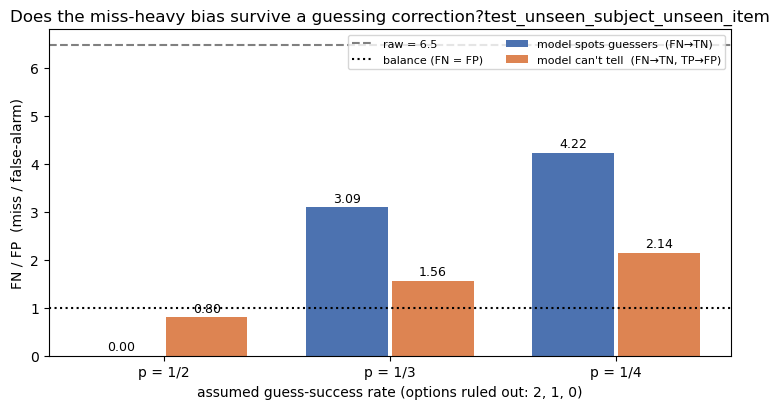

In [9]:
def guess_adjust(counts, p, mode="proportional"):
    """Reweight FP/FN for a guess-success rate p. See markdown above for the model."""
    TP, TN, FP, FN = (int(counts[q]) for q in ["TP", "TN", "FP", "FN"])
    n_lucky = (TN + FP) * p / (1 - p)          # lucky correct guesses hidden in human-correct
    if mode == "excuse_misses":                # model perfectly flags non-knowers -> FN only
        moved = min(n_lucky, FN)
        return {"FP": float(FP), "FN": FN - moved, "n_lucky": n_lucky}
    if mode == "proportional":                 # model can't tell -> split TP:FN by size
        hc = TP + FN
        return {"FP": FP + n_lucky * TP / hc, "FN": FN - n_lucky * FN / hc, "n_lucky": n_lucky}
    raise ValueError(mode)


GUESS_REGIME = REGIME   # analyse the regime selected above; change REGIME to switch
gtrials = build_trial_prediction_table(preds, GUESS_REGIME)
gcounts = gtrials["quadrant"].value_counts().reindex(["TP", "TN", "FP", "FN"]).fillna(0).astype(int)
raw_ratio = gcounts["FN"] / gcounts["FP"]

rows = [{"scenario": "raw", "mode": "-", "FP": float(gcounts["FP"]), "FN": float(gcounts["FN"]),
         "FN/FP": raw_ratio, "n_lucky": 0.0}]
P_VALUES = [("1/2", 1/2), ("1/3", 1/3), ("1/4", 1/4)]
for name, p in P_VALUES:
    for mode in ("excuse_misses", "proportional"):
        a = guess_adjust(gcounts, p, mode)
        rows.append({"scenario": f"guess {name}", "mode": mode, "FP": a["FP"], "FN": a["FN"],
                     "FN/FP": a["FN"] / a["FP"] if a["FP"] else float("inf"), "n_lucky": a["n_lucky"]})

adj_df = pd.DataFrame(rows)
print(f"Regime: {GUESS_REGIME}")
print(f"Raw: FP={int(gcounts['FP'])}, FN={int(gcounts['FN'])}, FN/FP={raw_ratio:.2f}")
print(adj_df.to_string(index=False, float_format=lambda x: f"{x:8.1f}"))

# --- FN/FP ratio across guess scenarios, bracketed by the two accounting bounds ---
MODE_LABELS = {
    "excuse_misses": "model spots guessers  (FN→TN)",
    "proportional":  "model can't tell  (FN→TN, TP→FP)",
}

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(P_VALUES))
for mode, color, off in [("excuse_misses", "#4C72B0", -0.19), ("proportional", "#DD8452", 0.19)]:
    vals = [guess_adjust(gcounts, p, mode) for _, p in P_VALUES]
    ratios = [a["FN"] / a["FP"] if a["FP"] else np.nan for a in vals]
    bars = ax.bar(x + off, ratios, width=0.36, color=color, label=MODE_LABELS[mode])
    ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
ax.axhline(raw_ratio, ls="--", c="grey", label=f"raw = {raw_ratio:.1f}")
ax.axhline(1.0, ls=":", c="black", label="balance (FN = FP)")
ax.set_xticks(x); ax.set_xticklabels([f"p = {n}" for n, _ in P_VALUES])
ax.set_xlabel("assumed guess-success rate (options ruled out: 2, 1, 0)")
ax.set_ylabel("FN / FP  (miss / false-alarm)")
ax.set_title(f"Does the miss-heavy bias survive a guessing correction?{GUESS_REGIME}")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


excuse_misses — assume all lucky guesses were ones the model called "wrong" → they all go FN → TN. TP and FP untouched. (Why FN drops so fast.)


proportional — lucky guesses split by the current TP:FN ratio → the FN-share goes FN → TN, the TP-share goes TP → FP.

## Guessing correction across all three test regimes

The same FN/FP guessing correction as above, applied to each held-out test regime. Reuses
`guess_adjust` and `build_trial_prediction_table` from the cells above. Y-axes are shared so
the regimes are directly comparable; each panel notes its own trial count and raw FN/FP.


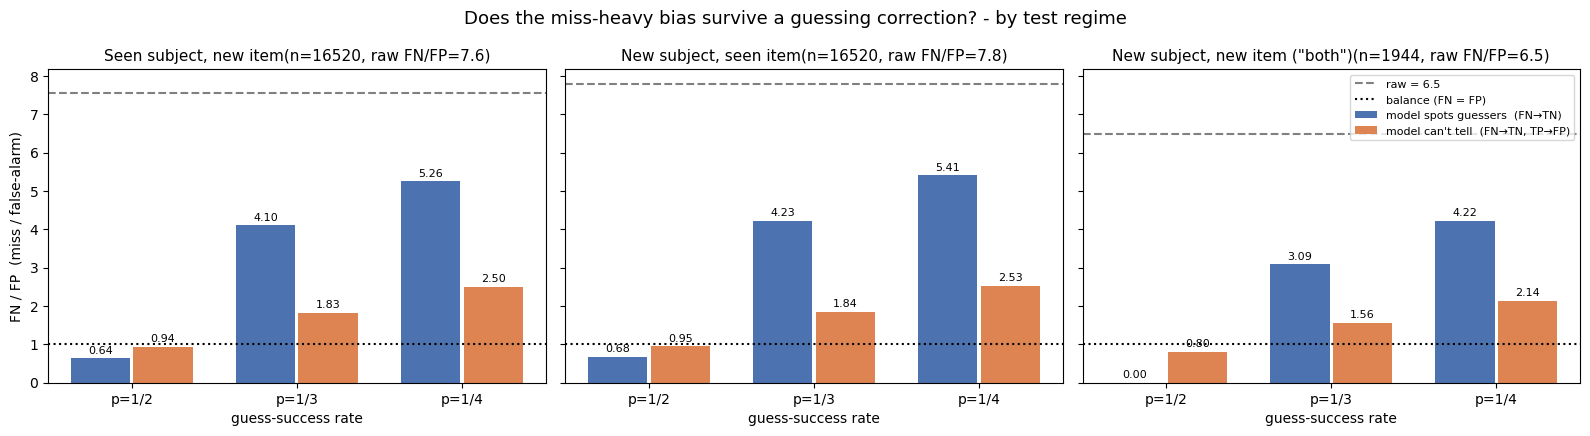

                         regime  scenario          mode       FP       FN    FN/FP
  test_seen_subject_unseen_item       raw             -    377.0   2852.0      7.6
  test_seen_subject_unseen_item guess 1/2 excuse_misses    377.0    240.0      0.6
  test_seen_subject_unseen_item guess 1/3 excuse_misses    377.0   1546.0      4.1
  test_seen_subject_unseen_item guess 1/4 excuse_misses    377.0   1981.3      5.3
  test_seen_subject_unseen_item guess 1/2  proportional   2453.4   2316.4      0.9
  test_seen_subject_unseen_item guess 1/3  proportional   1415.2   2584.2      1.8
  test_seen_subject_unseen_item guess 1/4  proportional   1069.1   2673.5      2.5
  test_unseen_subject_seen_item       raw             -    364.0   2833.0      7.8
  test_unseen_subject_seen_item guess 1/2 excuse_misses    364.0    246.0      0.7
  test_unseen_subject_seen_item guess 1/3 excuse_misses    364.0   1539.5      4.2
  test_unseen_subject_seen_item guess 1/4 excuse_misses    364.0   1970.7      5.4
  te

In [10]:
TEST_REGIMES = [
    "test_seen_subject_unseen_item",
    "test_unseen_subject_seen_item",
    "test_unseen_subject_unseen_item",
]
REGIME_TITLES = {
    "test_seen_subject_unseen_item":   "Seen subject, new item",
    "test_unseen_subject_seen_item":   "New subject, seen item",
    "test_unseen_subject_unseen_item": 'New subject, new item ("both")',
}
P_VALUES = [("1/2", 1/2), ("1/3", 1/3), ("1/4", 1/4)]

MODE_LABELS = {
    "excuse_misses": "model spots guessers  (FN→TN)",
    "proportional":  "model can't tell  (FN→TN, TP→FP)",
}

fig, axes = plt.subplots(1, len(TEST_REGIMES), figsize=(16, 4.4), sharey=True)
table_rows = []

for ax, regime in zip(axes, TEST_REGIMES):
    t = build_trial_prediction_table(preds, regime)
    c = t["quadrant"].value_counts().reindex(["TP", "TN", "FP", "FN"]).fillna(0).astype(int)
    raw_ratio = c["FN"] / c["FP"]
    table_rows.append({"regime": regime, "scenario": "raw", "mode": "-",
                       "FP": float(c["FP"]), "FN": float(c["FN"]), "FN/FP": raw_ratio})

    x = np.arange(len(P_VALUES))
    for mode, color, off in [("excuse_misses", "#4C72B0", -0.19), ("proportional", "#DD8452", 0.19)]:
        ratios = []
        for name, p in P_VALUES:
            a = guess_adjust(c, p, mode)
            ratios.append(a["FN"] / a["FP"] if a["FP"] else np.nan)
            table_rows.append({"regime": regime, "scenario": f"guess {name}", "mode": mode,
                               "FP": a["FP"], "FN": a["FN"],
                               "FN/FP": a["FN"] / a["FP"] if a["FP"] else float("inf")})
        bars = ax.bar(x + off, ratios, width=0.36, color=color, label=MODE_LABELS[mode])
        ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

    ax.axhline(raw_ratio, ls="--", c="grey", label=f"raw = {raw_ratio:.1f}")
    ax.axhline(1.0, ls=":", c="black", label="balance (FN = FP)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"p={n}" for n, _ in P_VALUES])
    ax.set_title(f"{REGIME_TITLES[regime]}(n={len(t)}, raw FN/FP={raw_ratio:.1f})", fontsize=11)
    ax.set_xlabel("guess-success rate")

axes[0].set_ylabel("FN / FP  (miss / false-alarm)")
axes[-1].legend(fontsize=8)
fig.suptitle("Does the miss-heavy bias survive a guessing correction? - by test regime", fontsize=13)
plt.tight_layout()
plt.show()

adj_all_df = pd.DataFrame(table_rows)
print(adj_all_df.to_string(index=False, float_format=lambda x: f"{x:8.1f}"))
